<a href="https://colab.research.google.com/github/azrapatvi/Ml_practice/blob/main/15_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

In [7]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    centers=3,
    n_features=2,
    random_state=42
)

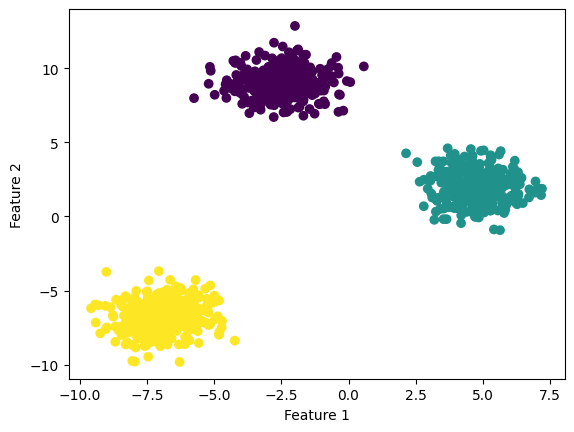

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [9]:
# standarization

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
from sklearn.cluster import KMeans

wcss=[] # within cluster sum of square.... this is to plot find the elbow point

for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled) # becuase unsupervised learnign dont need to give y trainn .....it learns the patterns from the unlabeled data
  wcss.append(kmeans.inertia_)

In [14]:
wcss


[1500.0000000000002,
 475.008282303635,
 48.32826902006254,
 41.128773224547395,
 35.19580456893844,
 33.45752327404626,
 26.231479530230718,
 23.695952459690595,
 21.507353952831696,
 19.531049345164977]

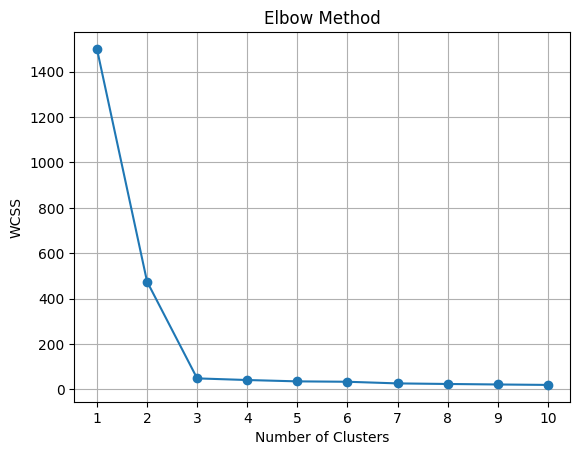

In [22]:
plt.plot(range(1,11),wcss,marker='o')

plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [24]:
# k=3

kmeans=KMeans(n_clusters=3,init='k-means++')

In [25]:
kmeans

KMeans(n_clusters=3)

In [30]:
kmeans.fit_predict(X_train_scaled)

array([0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2, 0, 1, 2, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 2, 0, 0, 2,
       2, 2, 1, 2, 2, 2, 1, 1, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 1, 1, 2, 1, 2, 0, 1, 2, 2, 0,
       2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 2, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0, 1, 1, 0,
       1, 2, 1, 0, 1, 2, 0, 2, 1, 2, 2, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       0, 0, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1,
       0, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 1, 1, 2, 0, 1, 0, 1, 0, 1, 0, 2,
       2, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 2, 0, 2, 2, 1, 0, 0, 0, 1,
       1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 2,
       1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2,
       1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 0, 2, 0, 1,
       1, 1, 0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 1, 2, 1,

In [31]:
y_pred=kmeans.predict(X_test_scaled)

In [32]:
pd.DataFrame({
    "actual":y_test,
    "predicted":y_pred
})

,actual,predicted
0,0,0
1,2,1
2,2,1
3,1,2
4,0,0
...,...,...
245,0,0
246,0,0
247,0,0
248,1,2


In [33]:
X_test_scaled

array([[-2.04302638e-01,  1.40539101e+00],
       [-9.91061186e-01, -1.33339228e+00],
       [-1.02419928e+00, -1.38794572e+00],
       [ 1.13019429e+00, -1.23483758e-02],
       [ 1.16489239e-01,  1.26604715e+00],
       [-1.23222256e+00, -1.23268116e+00],
       [ 1.59699078e+00, -1.06677071e-01],
       [-1.62030203e-01,  1.15033500e+00],
       [ 9.41343653e-01,  3.42269750e-03],
       [-5.63103025e-02,  1.17467425e+00],
       [-3.03334960e-01,  1.07701149e+00],
       [ 1.40141966e+00,  3.52137381e-01],
       [ 2.99396720e-02,  1.26976113e+00],
       [-1.40003234e-01,  1.29794905e+00],
       [-1.01346302e-01,  1.38336303e+00],
       [-8.20152611e-01, -1.32642759e+00],
       [-1.03677863e+00, -1.33338018e+00],
       [ 1.45937691e+00,  4.07907829e-01],
       [-1.06738268e+00, -1.13464367e+00],
       [-1.08940367e+00, -1.51152982e+00],
       [-8.55387145e-01, -1.19886559e+00],
       [-1.64085255e-01,  9.57441460e-01],
       [-7.16088126e-01,  1.02624609e+00],
       [ 1.

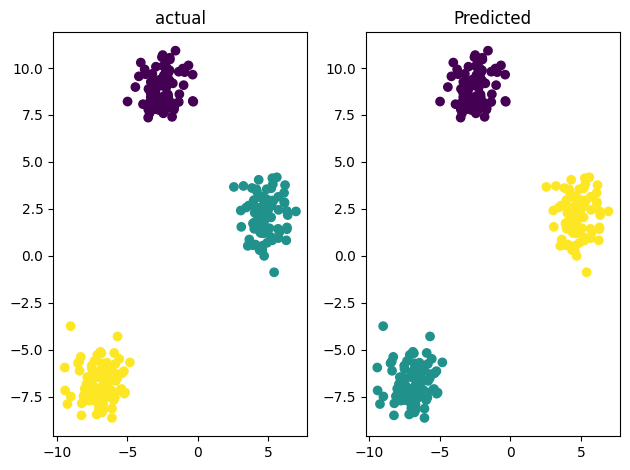

In [42]:
plt.subplot(1,2,1)
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.title("actual")

plt.subplot(1, 2, 2)
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.title("Predicted")

plt.tight_layout()
plt.show()


validated the datset

In [43]:
!pip install kneed

In [44]:
# validating kvalue
# knee locator
# silhouette

from kneed import KneeLocator

kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')


In [46]:
kl.elbow

np.int64(3)

so by this we can get the k value...